run this headless

conda activate guitarmidi
screen jupyter nbconvert --to notebook --execute traning.ipynb --output=output_notebook.ipynb --ExecutePreprocessor.timeout=-1



In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files

input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'
input_filepaths = sorted(glob.glob(os.path.join(input_data_dir, '**', 'input', '*.npy'), recursive=True))
output_filepaths=sorted(glob.glob(os.path.join(input_data_dir, '**', 'output', '*.npy'), recursive=True))
# The limit of samples with midi notes off to be put into the trainingset

# sailent_thresh=20000 
# current_sailent_count=np.zeros(89,dtype=int)
# selected_outfiles=[]
# selected_infiles=[]
 
# rng=np.random.default_rng(123)
# perm=rng.permutation(len(output_filepaths))
# output_filepaths=[output_filepaths[i] for i in perm]
# input_filepaths=[input_filepaths[i] for i in perm]
# # for i,output_filepath in enumerate(output_filepaths):
# #     output_data=np.load(output_filepath)


#     # # print(output_data.shape)
#     # # print("out path:", output_filepath)
#     # # print("in path:", input_filepaths[i])
#     # if output_data[0][88]>0:
#     #     if current_sailent_count[88]<sailent_thresh:
#     #         selected_outfiles.append(output_filepath)
#     #         selected_infiles.append(input_filepaths[i])
#     #         current_sailent_count[88]+=1
#     # else:
#     #     selected_outfiles.append(output_filepath)
#     #     selected_infiles.append(input_filepaths[i])


# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)
#     copydata=True
#     for note in range(89):
#         if output_data[0][note]>0:
#             if current_sailent_count[note]>sailent_thresh:
#                 copydata=False

#     # print(output_data.shape)
#     # print("out path:", output_filepath)
#     # print("in path:", input_filepaths[i])

#     if copydata:
#         selected_outfiles.append(output_filepath)
#         selected_infiles.append(input_filepaths[i])
#         for note in range(89):
#             if output_data[0][note]>0:
#                 current_sailent_count[note]+=1
# input_filepaths=selected_infiles
# output_filepaths=selected_outfiles
print("selected files: input: ",len(input_filepaths),", output: ",len(output_filepaths))

I0000 00:00:1762500297.228824  110792 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1762500297.252069  110792 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1762500297.707627  110792 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
W0000 00:00:1762500298.164031  110792 gpu_device.cc:2456] TensorFlow was not built with CUDA kernel bi

--- Input to FASTBlock will have a feature map size of: 72x64 ---


Model: "FAST_AudioSpectrogramTransformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 312, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 156, 128, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 156, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 156, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 78, 64, 192)    │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 78, 64, 192)    │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 78, 64, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 72, 64, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_block_0 (FASTBlock)        │ (None, 72, 64, 384)    │     2,733,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_block_1 (FASTBlock)        │ (None, 72, 64, 384)    │     3,397,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_block_2 (FASTBlock)        │ (None, 72, 64, 384)    │     3,397,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fast_block_3 (FASTBlock)        │ (None, 72, 64, 384)    │     3,397,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 384)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 89)             │        34,265 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,016,185 (49.65 MB)

 Trainable params: 13,015,737 (49.65 MB)

 Non-trainable params: 448 (1.75 KB)

selected files: input:  340339 , output:  340339


Model Architecture:
--------------------------------------------------------------------------------
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 312, 256, 32)   │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 312, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 312, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 312, 256, 32)   │             0 │
│ (SpatialDropout2D)            

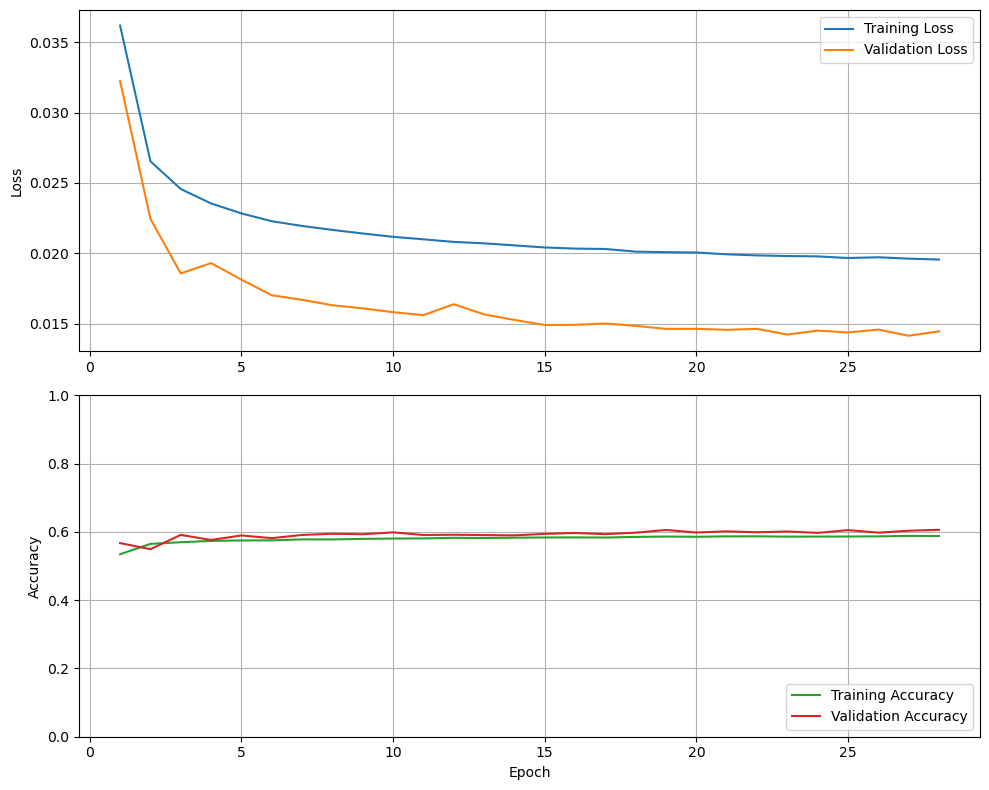


Epoch 28: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
3723/3723 ━━━━━━━━━━━━━━━━━━━━ 430s 116ms/step - accuracy: 0.5882 - loss: 0.0195 - val_accuracy: 0.6063 - val_loss: 0.0144 - learning_rate: 0.0010
Epoch 28: early stopping
Restoring model weights from the end of the best epoch: 23.
Model weights saved successfully!


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
# NO Keras backend import needed now
from model import build_cnn_model # Assumes build_cnn_model is in model.py
import common
from common import INPUT_SHAPE, OUTPUT_DIM_NOTES
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import glob # To list files
import datetime
# --- 1. GPU Setup ---
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable Mixed Precision
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision policy set to 'mixed_float16'.")

        for gpu in gpus:
            # Enable memory growth
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled for GPUs.")
    except RuntimeError as e:
        print(f"Error configuring GPU: {e}")
# ---------------------------------------------------------------------------------

print(f"TensorFlow version: {tf.__version__}")

# --- 2. Configuration ---
LEARNING_RATE = 0.001
BATCH_SIZE = 64 
EPOCHS = 100


# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training/output'
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'


# --- 4. Model Definition and Compilation (Using built-in loss) ---

cnn_model = build_cnn_model(common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES)
cnn_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE,clipnorm=1.0), # <-- ADDED CLIPNORM
                  loss='binary_crossentropy', # <-- USING BUILT-IN LOSS
                  metrics=['accuracy'])

cnn_model.summary()


# --- 5. Custom Callback for Live Loss Plotting (omitted for brevity, assume definition remains the same) ---
class PlotLoss(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.losses = []
        self.val_losses = []
        self.acc = []
        self.val_acc = []
        self.epochs_run = []
        self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(2, 1, figsize=(10, 8))
            # Save model summary to string
        summary_list = []
        self.model.summary(print_fn=lambda x: summary_list.append(x))
        self.model_summary = '\n'.join(summary_list)
        
        # Save summary to file
        with open('model_summary.txt', 'w') as f:
            f.write(self.model_summary)

    def on_epoch_end(self, epoch, logs=None):
        # local import so notebook output display works even when executed headless
        from IPython.display import display, Image, clear_output

        logs = logs or {}
        self.epochs_run.append(epoch + 1)

        # safe conversion to numbers (use NaN if missing)
        self.losses.append(float(logs.get('loss')) if logs.get('loss') is not None else np.nan)
        self.val_losses.append(float(logs.get('val_loss')) if logs.get('val_loss') is not None else np.nan)

        # support both 'accuracy' and 'acc' keys
        acc_val = logs.get('accuracy') if 'accuracy' in logs else logs.get('acc')
        val_acc_val = logs.get('val_accuracy') if 'val_accuracy' in logs else logs.get('val_acc')
        self.acc.append(float(acc_val) if acc_val is not None else np.nan)
        self.val_acc.append(float(val_acc_val) if val_acc_val is not None else np.nan)

        # clear previous cell output, draw and save figure, then display saved PNG so it remains in notebook
        clear_output(wait=True)
        # Print model summary first
        print("Model Architecture:")
        print("-" * 80)
        print(self.model_summary)
        print("-" * 80)
        #print(f"\nTraining Progress - Epoch {epoch + 1}/{self.model.epochs}")

        # Loss subplot
        self.ax_loss.clear()
        self.ax_loss.plot(self.epochs_run, self.losses, label='Training Loss', color='tab:blue')
        if any(~np.isnan(self.val_losses)):
            self.ax_loss.plot(self.epochs_run[:len(self.val_losses)], self.val_losses, label='Validation Loss', color='tab:orange')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.legend(loc='upper right')
        self.ax_loss.grid(True)

        # Accuracy subplot
        self.ax_acc.clear()
        self.ax_acc.plot(self.epochs_run, self.acc, label='Training Accuracy', color='tab:green')
        if any(~np.isnan(self.val_acc)):
            self.ax_acc.plot(self.epochs_run[:len(self.val_acc)], self.val_acc, label='Validation Accuracy', color='tab:red')
        self.ax_acc.set_xlabel('Epoch')
        self.ax_acc.set_ylabel('Accuracy')
        self.ax_acc.set_ylim(0.0, 1.0)
        self.ax_acc.legend(loc='lower right')
        self.ax_acc.grid(True)

        self.fig.tight_layout()
        self.fig.savefig("training.png", bbox_inches='tight')  # persist image
        display(Image("training.png"))  # embed PNG in notebook output so it remains visible
        plt.close(self.fig)  # close to free memory; will recreate on next epoch

# --- 6. Data Loading and Preparation (Modified to include weights) ---


# output_filepaths = sorted(glob.glob(os.path.join(output_data_dir, '*.npy')))

total_samples_on_disk = len(input_filepaths)
# if total_samples_on_disk == 0 or total_samples_on_disk != len(output_filepaths):
#     print("ERROR: Data files not found or mismatch.")
#     exit()

print(f"Found {total_samples_on_disk} files on disk.")

# We need to map the data to (feature, label, weight) tuples for tf.data
# The weight for each sample will be the 'element_weights' vector defined above.

def load_sample_from_files(input_path_tensor):
    input_path = input_path_tensor.numpy().decode('utf-8')
    inputname=os.path.basename(input_path)
    
    parentdir=os.path.dirname(os.path.dirname(input_path))
    # print("current dir: "+parentdir)
    output_path=os.path.join(parentdir,'output',inputname)

    # print("input: "+input_path)
    # print("output: "+output_path)
    # Load data
    image = np.load(input_path).astype(np.float32).reshape(INPUT_SHAPE)
    label = np.load(output_path).astype(np.float32).reshape(common.OUTPUT_DIM_NOTES)

    # Ensure shape
    image = tf.ensure_shape(image, INPUT_SHAPE)
    label = tf.ensure_shape(label, (common.OUTPUT_DIM_NOTES,)) 
    
    # Return features and label
    return image, label


def tf_load_sample_from_files(ipath):
    image, label = tf.py_function(
        load_sample_from_files, [ipath], [tf.float32, tf.float32]
    )
    image.set_shape(INPUT_SHAPE)
    label.set_shape((common.OUTPUT_DIM_NOTES,))
    return image, label # Return (features, labels, sample_weights)
def batch_with_weights(dataset):
    def _stack_fn(images, labels, weights):
        return (tf.stack(images), tf.stack(labels), tf.stack(weights))
    return dataset.batch(BATCH_SIZE).map(_stack_fn, num_parallel_calls=tf.data.AUTOTUNE)

# Create a dataset from the lists of file paths
dataset = tf.data.Dataset.from_tensor_slices((input_filepaths))
dataset = dataset.shuffle(buffer_size=total_samples_on_disk)

split_ratio = 0.7
num_train = int(total_samples_on_disk * split_ratio)

train_dataset = dataset.take(num_train)
val_dataset = dataset.skip(num_train)

# Map loading function (now includes the weight vector)
train_dataset = train_dataset.map(tf_load_sample_from_files, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.map(tf_load_sample_from_files, num_parallel_calls=tf.data.AUTOTUNE)

# Apply batching and prefetching  (use train/val_dataset.cache().batch... if needed)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
# train_dataset = batch_with_weights(train_dataset).prefetch(tf.data.AUTOTUNE)
# val_dataset = batch_with_weights(val_dataset).prefetch(tf.data.AUTOTUNE)

# --- 7. Training the Model (Passing the element-wise weight) ---

plot_callback = PlotLoss()
early_stopping_callback = EarlyStopping(
    monitor='val_loss', 
    patience=5,   
    min_delta=0.0001, 
    mode='min',          
    verbose=1,           
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
checkpoint=ModelCheckpoint('checkpoints/guitarmidi_epoch{epoch:02d}_valAcc{val_accuracy:.4f}.weights.h5', save_weights_only=True,save_freq='epoch')
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir,
        histogram_freq=1,  # Log weight histograms every epoch
        write_graph=True,
        write_images=True,
        update_freq='epoch',
        profile_batch='10,20',  # Profile batches 10-20 for performance analysis
        embeddings_freq=1)
# initial_learning_rate = LEARNING_RATE
# warmup_epochs = 5

# class WarmUpLearningRateScheduler(tf.keras.callbacks.Callback):
#     def __init__(self, warmup_epochs, initial_lr):
#         super().__init__()
#         self.warmup_epochs = warmup_epochs
#         self.initial_lr = initial_lr
        
#     def on_epoch_begin(self, epoch, logs=None):
#         if epoch < self.warmup_epochs:
#             lr = self.initial_lr * ((epoch + 1) / self.warmup_epochs)
#             tf.keras.backend.set_value(self.model.optimizer.learning_rate, lr)
#             print(f'\nEpoch {epoch+1}: WarmUp LR set to {lr}')

# warmup = WarmUpLearningRateScheduler(warmup_epochs, initial_learning_rate)

print("\n--- Starting CNN Model Training with Sample Weights ---")
try:
    # Keras expects (features, labels, sample_weights) when sample_weights are present
    history_cnn = cnn_model.fit(train_dataset,
                                epochs=EPOCHS,
                                validation_data=val_dataset,
                                callbacks=[plot_callback, early_stopping_callback,checkpoint,reduce_lr,tensorboard_callback])
    
    cnn_model.save_weights('guitarmidi.weights.h5')
    print("Model weights saved successfully!")
    
except Exception as e:
    print(f"An error occurred during training: {e}")